# Imports der Bibliotheken

In [1]:
#Masterprojekt SFH - 1 Verbraucher, 1 Wärmepumpe, 1 Speicher
import logging
logger = logging.getLogger("gurobipy")
logger.propagate = False

import pandas as pd
import pypsaheat as ph
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Einlesen Lastgänge & Zuordnung der Daten

In [2]:
#Einlesen der Lastgänge
input_data = pd.read_csv('Inputs/load_profile.csv', index_col=0)
input_data

,electricity,PV,temp,heat_water,heat_space
index,,,,,
0,0.343,0.000,-2.620,0.029,2.272
1,0.102,0.000,-3.313,0.036,2.336
2,0.185,0.000,-3.869,0.029,2.416
3,0.199,0.000,-4.301,0.053,2.576
4,0.297,0.000,-4.747,0.127,2.976
...,...,...,...,...,...
163,0.840,0.039,13.508,0.338,2.752
164,0.676,0.000,11.191,0.350,2.608
165,0.509,0.000,10.786,0.300,2.288


<Axes: xlabel='index'>

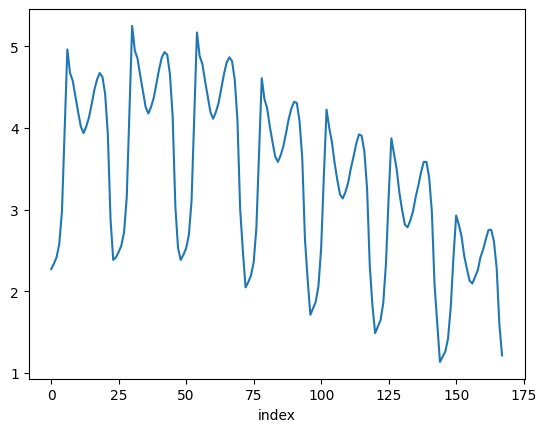

In [3]:
#Zuordnung der Daten aus den Lastgängen
raumwaerme = input_data['heat_space'] #Heizlast von SFH in kW
raumwaerme.plot()

<Axes: xlabel='index'>

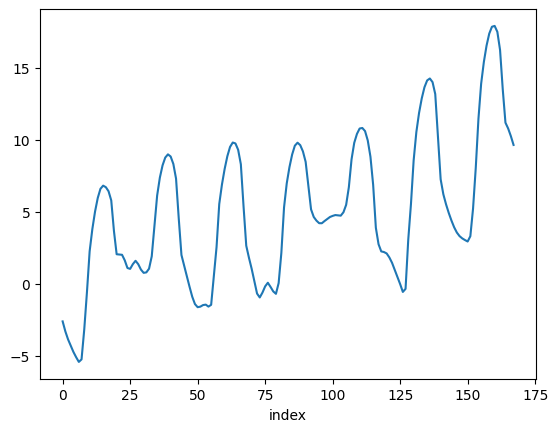

In [4]:
# aussentemperatur = df_data_weather['DE_temperature']
aussentemperatur = input_data['temp']
aussentemperatur.plot()

<Axes: xlabel='index'>

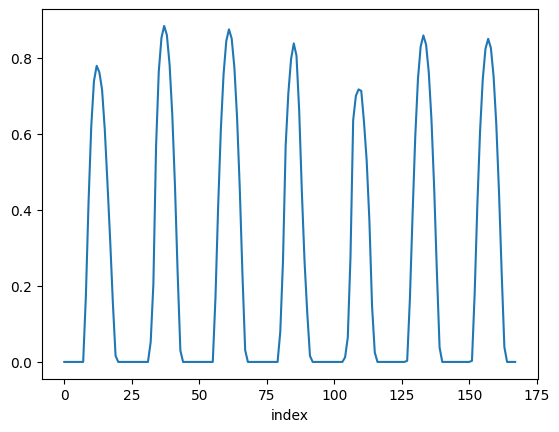

In [5]:
#Strahlung
solarthermie_strahlung = input_data["PV"]
solarthermie_strahlung.plot()

# System Eigenschaften

In [6]:
#Wärmespeicher Eigenschaften 
Store_height = 2 #m
Store_base = 0.8 #m²
Store_layer = 3

T_Warmwasser = 55

#Wärmepumpen Leistung
HP_power = 20 #kW Wärmepumpenleistung

#Strom
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug
grid_power = np.inf #kW Hausanschluss Leistung

<Axes: xlabel='index'>

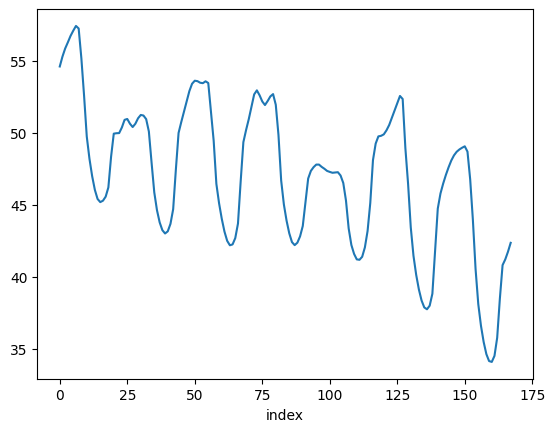

In [7]:
# Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, aussentemperatur)
T_flow.plot()

# Modellerstellung

In [8]:
# Aufbau des Modells
n = ph.HeatNetwork()

n.set_snapshots(input_data.index)

n.add("Bus",  
      name = "electricity"      
)

n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
  )

n.add('Load', 
      bus = 'electricity', 
      name = 'Elektrische Last',
      #p_set = power_demand_hp
)

# Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = input_data['heat_space'],
      T_demand = T_flow
      )

# Hinzufügen eines Schichtspeichers mit konstanten Volumschichten
n.add('HeatStore',
      name='hs',
      constant='volume',
      height=Store_height,
      base=Store_base,
      N_layer=Store_layer,       
      cyclic=False,
      U_wall=0,                 
      T_initial=[55, 50, 45]     # numerische Liste (Länge = N_layer) oder single float
)

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp1',
      bus0 = 'electricity',
      p_nom = HP_power,          # Nennleistung (thermal kW)
      m_nom = 700, # kg/h 
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_nom = 65,
      heat_source  = 'air'
      )

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp2',
      bus0 = 'electricity',
      p_nom = HP_power,          # Nennleistung (thermal kW)
      m_nom = 700, # kg/h 
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_nom = 50,
      heat_source  = 'air'
      )

# Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp3',
      bus0 = 'electricity',
      p_nom = HP_power,          # Nennleistung (thermal kW)
      m_nom = 700, # kg/h 
      heat_store = 'hs',
      T_source = input_data['temp'],
      T_nom = 45,
      heat_source  = 'air'
      )
#Hinzufügen der Warmwasserlast
# n.add('HeatLoad',
#       name = 'heat_water_demand',
#       heat_store = 'hs',
#       p_set = input_data['DE_heat_profile_water_SFH']/1000,
#       T_demand = T_Warmwasser
#       )

In [9]:
n.heat_loads

attribute,heat_store,carrier,type,p_set,T_demand,T_diff_return,internal_exchange,outlet_height,inlet_height
HeatLoad,,,,,,,,,
heat_space_demand,hs,,,0.0,50.0,10.0,False,1.0,0.0


# Optimierung

In [10]:
# Optimierung mit rollierendem Horizont
n.optimize.optimize_with_rolling_horizon(horizon = 24, overlap = 12)

INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [0:23] (1/14).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.09s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-fuqy_jtm.lp
Reading time = 0.01 seconds
obj: 1392 rows, 456 columns, 3717 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 1392 rows, 456 columns and 3717 nonzeros
Model fingerprint: 0xbfa917f9
Variable types: 384 continuous, 72 integer (72 binary)
Coefficient statistics:
  Matrix range     [7e-04, 1e+02]
  Objective range  [3e-01, 3e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 487 rows and 123 columns
Presolve time: 0.01s
Presolved: 905 rows, 333 columns, 3259 nonzeros
Variable types: 267 continuous, 66 integer (66 binary)

Root relaxatio

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 456 primals, 0 duals
Objective: 1.59e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [12:35] (2/14).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


...

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 456 primals, 0 duals
Objective: 3.90e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.
INFO:pypsaheat.optimization.optimize:Optimizing network for snapshot horizon [156:167] (14/14).
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username
Set parameter LicenseID to value 2756558
Academic license - for non-commercial use only - expires 2026-12-18


INFO:linopy.io: Writing time: 0.08s


Read LP format model from file C:\Users\robin\AppData\Local\Temp\linopy-problem-b8fmnxgp.lp
Reading time = 0.01 seconds
obj: 696 rows, 228 columns, 1857 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 245K, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 696 rows, 228 columns and 1857 nonzeros
Model fingerprint: 0xa205f869
Variable types: 192 continuous, 36 integer (36 binary)
Coefficient statistics:
  Matrix range     [7e-04, 1e+02]
  Objective range  [3e-01, 3e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+100]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 204 rows and 48 columns
Presolve time: 0.01s
Presolved: 492 rows, 180 columns, 1743 nonzeros
Variable types: 144 continuous, 36 integer (36 binary)

Root relaxation: 

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 228 primals, 0 duals
Objective: 2.15e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


In [11]:
#Zuordnung der Ergebnisse
m = n.optimize.create_model()

Index(['electricity'], dtype='object', name='Bus')


In [12]:
#Inhalte der Optimierung
m

Linopy MILP model

Variables:
----------
 * Generator-p (snapshot, Generator)
 * HeatStore-hs-T_layer (snapshot, layer)
 * HeatPump-status (snapshot, HeatPump)
 * HeatPump-hp1-T_supply (snapshot, HeatPump)
 * HeatPump-hp2-T_supply (snapshot, HeatPump)
 * HeatPump-hp3-T_supply (snapshot, HeatPump)
 * HeatPump-hp1-T_bin_layer_hs (snapshot, layer)
 * HeatPump-hp2-T_bin_layer_hs (snapshot, layer)
 * HeatPump-hp3-T_bin_layer_hs (snapshot, layer)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * HeatStore-hs-layer_balance (snapshot, layer)
 * HeatStore-hs-max_layer_temp (snapshot, layer)
 * HeatStore-hs-only_one_hp_active (snapshot)
 * HeatPump-hp1-max_T_bin_layer_hs (HeatPump, snapshot, layer)
 * HeatPump-hp1-min_T_bin_layer_hs (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_bin_layer_eq_T_layer_hs_max (HeatPump, snapshot, layer)
 * HeatPump-hp1-T_bin_layer_eq_T_layer_hs_min 

In [13]:
# Berechnung
anzahl_laufend = (n.heat_pumps_t["status"] > 0).sum(axis=1)
mehrere_laufen = anzahl_laufend > 1

# Zusammenfügen in einen DataFrame
df_export = pd.DataFrame({
    'anzahl_laufende_hps': anzahl_laufend,
    'mehrere_laufen':      mehrere_laufen
})

# Als CSV speichern
df_export.to_csv('Outputs/konstanterTemperaturspeicher 3 WP/hp_status_check.csv', index=True, sep=';')
print("✅ Gespeichert: hp_status_check.csv")

✅ Gespeichert: hp_status_check.csv


In [27]:
heatstore_daten=n.heat_stores_t.T

In [28]:
hs_m = heatstore_daten['hs'].mean(axis=1)

# Python Ergebnisse

In [17]:
print("p_heat columns:", p_heat.columns)
print("COP columns:", COP.columns)
print("p_heat column levels:", p_heat.columns.nlevels)

p_heat columns: Index([65.0, 50.0, 45.0], dtype='float64', name='Temperature')
COP columns: Index([65.0, 50.0, 45.0], dtype='float64', name='Temperature')
p_heat column levels: 1


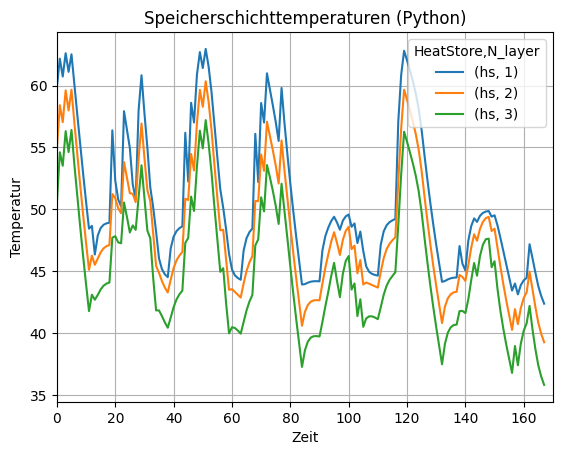

In [19]:
n.heat_stores_t.T.plot()
plt.title('Speicherschichttemperaturen (Python)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/py_speicherschichten.png')
plt.show()


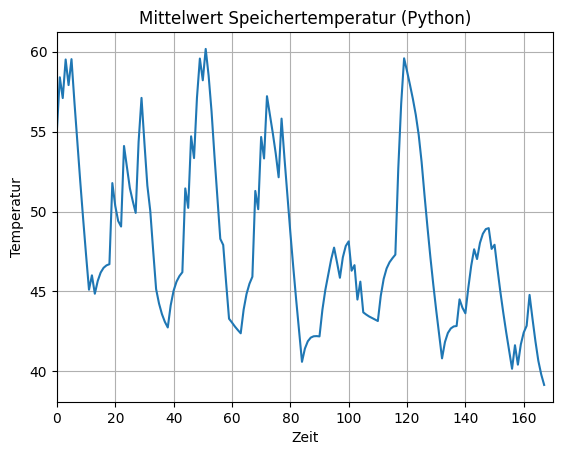

In [20]:
#Zuordnung der Ergebnisse aus dem Modell
#WP-Daten 
p_elec = n.heat_pumps_t.p_elec
p_heat = n.heat_pumps_t.p_heat
m_flow = n.heat_pumps_t.m_flow
COP = n.heat_pumps_t.COP
status = n.heat_pumps_t.status

#Mitteltemperatur der Schichten
hs_m = heatstore_daten['hs'].mean(axis=1)
hs_m.plot()
plt.title('Mittelwert Speichertemperatur (Python)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/py_speicherschichten_m.png')
plt.show()

In [21]:
# Berechnung der Kosten für den Netzbezug durch die Wärmepumpe
cost_grid = p_elec * grid_cost
total_cost_grid = cost_grid.sum().sum()

print(f"Kosten Netzbezug durch WP: {total_cost_grid:.2f} €")

Kosten Netzbezug durch WP: 84.56 €


# TRNSYS Ergebnisse

In [22]:
TRNSYSinputs = [
    "Inputs/TRNSYS/TRNSYSMassenstromHausseitig.csv",
    "Inputs/TRNSYS/TRNSYSRaumwärmebedarf.csv",
    "Inputs/TRNSYS/TRNSYSRücklauftemperatur.csv",
    "Inputs/TRNSYS/TRNSYSspeichermitteltemperatur.csv",
    "Inputs/TRNSYS/TRNSYSspeicherschichttemperaturen.csv",
    "Inputs/TRNSYS/TRNSYSWärmepumpe.csv"
]

df_liste = []

for f in TRNSYSinputs:
    df = pd.read_csv(f, encoding='latin1', skipinitialspace=True, engine='python', quoting=3, sep=',')
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    if 'TIME' in df.columns:
        df = df[pd.to_numeric(df['TIME'], errors='coerce').notnull()]
        df = df.apply(pd.to_numeric, errors='coerce')
        df['TIME'] = df['TIME'].round(2)
        df = df.set_index('TIME')
    
    df_liste.append(df)

TRNSYSdata = pd.concat(df_liste, axis=1).sort_index().reset_index()
TRNSYSdata = TRNSYSdata.rename(columns={'TIME':'Time', 'Massenstrom':'ts_m_heatspace', 'T_amb':'ts_T_amb', 'P_heatspace':'ts_P_heatspace', 'T_R':'ts_T_R', 'T_M':'ts_T_m', 'T_1':'ts_T_1', 'T_2':'ts_T_2','T_3':'ts_T_3', 'p_heat':'ts_P_heat', 'm_flow':'ts_m_flow'})
TRNSYSdata = TRNSYSdata.round(6)
TRNSYSdata

,Time,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_T_1,ts_T_2,ts_T_3,ts_P_heat,ts_m_flow
0,2112.0,195.627840,-2.620,2.272,49.884832,55.109029,59.884832,54.914720,50.527535,11.766,700.0
1,2113.0,201.138484,-3.313,2.336,51.658819,57.520326,61.658819,57.456059,53.446099,8.448,700.0
2,2114.0,208.026788,-3.869,2.416,51.902857,58.215993,61.902857,58.171412,54.573712,0.000,0.0
3,2115.0,221.803396,-4.301,2.576,52.481079,59.245558,62.481079,59.295973,55.959621,7.062,700.0
4,2116.0,256.244917,-4.747,2.976,52.421808,59.312031,62.421808,59.436535,56.077750,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...
163,2275.0,236.957666,13.508,2.752,39.075362,45.727051,49.075362,45.531795,42.573996,0.000,0.0
164,2276.0,224.558718,11.191,2.608,37.583750,44.291883,47.583750,44.216247,41.075652,0.000,0.0
165,2277.0,197.005501,10.786,2.288,36.272353,42.986783,46.272353,42.965696,39.722300,0.000,0.0
166,2278.0,137.766085,10.258,1.600,35.251959,41.960382,45.251959,41.960202,38.668986,0.000,0.0


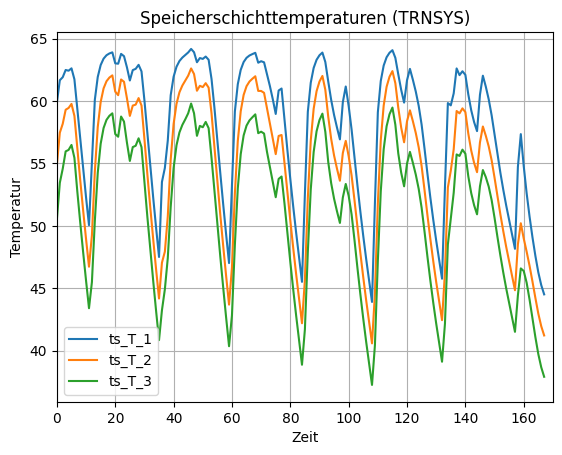

In [23]:
TRNSYS_T_s = TRNSYSdata[['ts_T_1', 'ts_T_2', 'ts_T_3']].copy()

TRNSYS_T_s.plot()
plt.title('Speicherschichttemperaturen (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/ts_speicherschichten.png')
plt.show()

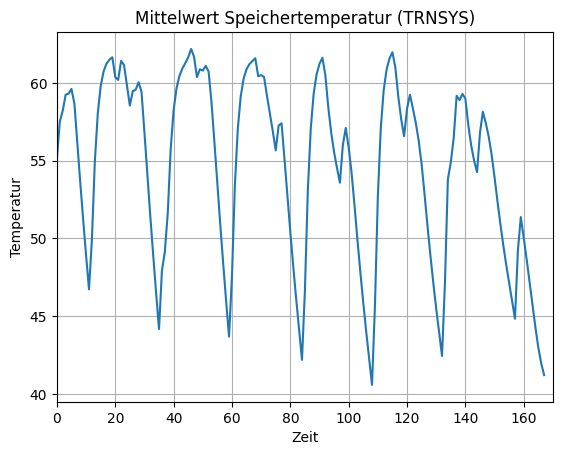

In [24]:
TRNSYS_T_m = TRNSYSdata['ts_T_m'].copy()

TRNSYS_T_m.plot()
plt.title('Mittelwert Speichertemperatur (TRNSYS)')
plt.xlabel('Zeit')
plt.ylabel('Temperatur')
plt.xlim(0, 170)
plt.grid()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/ts_speicherschichten_m.png')
plt.show()

# CSV-Ausgabe

In [32]:
# Kombinierten DataFrame erstellen
output_pypsa = pd.DataFrame({
    # hp1 (65°C)
    'py_P_elec_hp1': p_elec['hp1'].values,
    'py_P_heat_hp1': p_heat[65.0].values,
    'py_m_flow_hp1': m_flow['hp1'].values,
    'py_COP_hp1':    COP[65.0].values,
    'py_status_hp1': status['hp1'].values,

    # hp2 (50°C)
    'py_P_elec_hp2': p_elec['hp2'].values,
    'py_P_heat_hp2': p_heat[50.0].values,
    'py_m_flow_hp2': m_flow['hp2'].values,
    'py_COP_hp2':    COP[50.0].values,
    'py_status_hp2': status['hp2'].values,

    # hp3 (45°C)
    'py_P_elec_hp3': p_elec['hp3'].values,
    'py_P_heat_hp3': p_heat[45.0].values,
    'py_m_flow_hp3': m_flow['hp3'].values,
    'py_COP_hp3':    COP[45.0].values,
    'py_status_hp3': status['hp3'].values,

    # Speicher & Temperaturen
    'py_T_1': heatstore_daten['hs'][1].values.flatten(),
    'py_T_2': heatstore_daten['hs'][2].values.flatten(),
    'py_T_3': heatstore_daten['hs'][3].values.flatten(),
    'py_T_m': hs_m.values.flatten(),
})

output_pypsa = output_pypsa.round(6)
output_pypsa.to_csv(
    "Outputs/konstanterTemperaturspeicher 3 WP/output_pypsa - 3 Wochen.csv",
    sep=",",
    index_label="index",
    float_format="%.3f"
)

In [33]:
output_combined = pd.concat([output_pypsa, TRNSYSdata], axis=1)
output_combined

,py_P_elec_hp1,py_P_heat_hp1,py_m_flow_hp1,py_COP_hp1,py_status_hp1,py_P_elec_hp2,py_P_heat_hp2,py_m_flow_hp2,py_COP_hp2,py_status_hp2,...,ts_m_heatspace,ts_T_amb,ts_P_heatspace,ts_T_R,ts_T_m,ts_T_1,ts_T_2,ts_T_3,ts_P_heat,ts_m_flow
0,7.791862,11.765712,700.0,1.51,1.0,0.0,0.0,0.0,2.19,0.0,...,195.627840,-2.620,2.272,49.884832,55.109029,59.884832,54.914720,50.527535,11.766,700.0
1,5.708260,8.448225,700.0,1.48,1.0,0.0,0.0,0.0,2.15,0.0,...,201.138484,-3.313,2.336,51.658819,57.520326,61.658819,57.456059,53.446099,8.448,700.0
2,0.000000,0.000000,0.0,1.46,0.0,0.0,0.0,0.0,2.12,0.0,...,208.026788,-3.869,2.416,51.902857,58.215993,61.902857,58.171412,54.573712,0.000,0.0
3,4.870076,7.061611,700.0,1.45,1.0,0.0,0.0,0.0,2.10,0.0,...,221.803396,-4.301,2.576,52.481079,59.245558,62.481079,59.295973,55.959621,7.062,700.0
4,0.000000,0.000000,0.0,1.44,0.0,0.0,0.0,0.0,2.07,0.0,...,256.244917,-4.747,2.976,52.421808,59.312031,62.421808,59.436535,56.077750,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,0.000000,0.000000,-0.0,2.25,-0.0,0.0,0.0,-0.0,3.23,-0.0,...,236.957666,13.508,2.752,39.075362,45.727051,49.075362,45.531795,42.573996,0.000,0.0
164,0.000000,0.000000,-0.0,2.12,-0.0,0.0,0.0,-0.0,3.06,-0.0,...,224.558718,11.191,2.608,37.583750,44.291883,47.583750,44.216247,41.075652,0.000,0.0
165,0.000000,0.000000,-0.0,2.10,-0.0,0.0,0.0,-0.0,3.03,-0.0,...,197.005501,10.786,2.288,36.272353,42.986783,46.272353,42.965696,39.722300,0.000,0.0
166,0.000000,0.000000,-0.0,2.07,-0.0,0.0,0.0,0.0,3.00,0.0,...,137.766085,10.258,1.600,35.251959,41.960382,45.251959,41.960202,38.668986,0.000,0.0


In [34]:
output_combined_ordered = output_combined.iloc[:, [11, 10, 9, 12, 0, 3, 4, 1, 18, 2, 19, 5, 15, 6, 16, 7, 17, 8, 14, 13, 12]]
output_combined_ordered.to_csv(
    "Outputs/konstanterTemperaturspeicher 3 WP/output_combined_ordered.csv",
    sep=",",
    index_label="index", 
    float_format="%.3f"     
)
output_combined_ordered

,py_P_heat_hp3,py_P_elec_hp3,py_status_hp2,py_m_flow_hp3,py_P_elec_hp1,py_COP_hp1,py_status_hp1,py_P_heat_hp1,py_T_m,py_m_flow_hp1,...,py_P_elec_hp2,py_T_1,py_P_heat_hp2,py_T_2,py_m_flow_hp2,py_T_3,py_COP_hp2,py_status_hp3,py_COP_hp3,py_m_flow_hp3
0,0.0,0.0,0.0,0.0,7.791862,1.51,1.0,11.765712,55.109029,700.0,...,0.0,59.884832,0.0,54.914720,0.0,50.527535,2.19,0.0,2.48,0.0
1,0.0,0.0,0.0,0.0,5.708260,1.48,1.0,8.448225,58.398316,700.0,...,0.0,62.173048,0.0,58.413675,0.0,54.608224,2.15,0.0,2.43,0.0
2,0.0,0.0,0.0,0.0,0.000000,1.46,0.0,0.000000,57.098148,0.0,...,0.0,60.730035,0.0,57.041470,0.0,53.522940,2.12,0.0,2.40,0.0
3,0.0,0.0,0.0,0.0,4.870076,1.45,1.0,7.061611,59.512074,700.0,...,0.0,62.612153,0.0,59.610234,0.0,56.313835,2.10,0.0,2.38,0.0
4,0.0,0.0,0.0,0.0,0.000000,1.44,0.0,0.000000,57.910543,0.0,...,0.0,61.110664,0.0,57.993094,0.0,54.627872,2.07,0.0,2.35,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,0.0,0.0,-0.0,-0.0,0.000000,2.25,-0.0,0.000000,43.302456,-0.0,...,0.0,46.057686,0.0,43.536450,-0.0,40.313233,3.23,-0.0,3.62,-0.0
164,0.0,0.0,-0.0,-0.0,0.000000,2.12,-0.0,0.000000,41.898964,-0.0,...,0.0,44.884298,0.0,42.105142,-0.0,38.707452,3.06,-0.0,3.44,-0.0
165,0.0,0.0,-0.0,-0.0,0.000000,2.10,-0.0,0.000000,40.667680,-0.0,...,0.0,43.788453,0.0,40.831085,-0.0,37.383502,3.03,-0.0,3.41,-0.0
166,0.0,0.0,0.0,-0.0,0.000000,2.07,-0.0,0.000000,39.806642,-0.0,...,0.0,42.995339,0.0,39.938716,0.0,36.485871,3.00,-0.0,3.37,-0.0


# Combined Plots

KeyError: 'py_status'

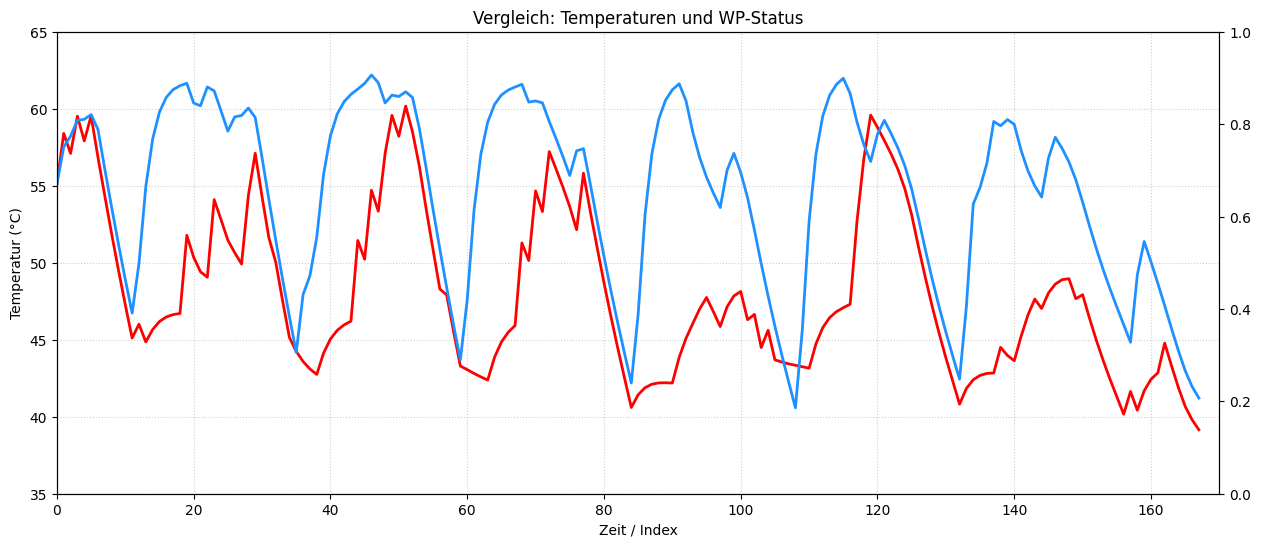

In [35]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# --- Linke y-Achse: Temperaturen ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=2, color='red')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=2, color='dodgerblue')

ax1.set_title('Vergleich: Temperaturen und WP-Status')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.set_ylim(35, 65) # Beispielhafter Bereich für Temperaturen
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Rechte y-Achse: WP Status (0 oder 1) ---
ax2 = ax1.twinx()
# drawstyle='steps-post' macht den An/Aus-Charakter deutlich
ax2.plot(output_pypsa.index, output_pypsa['py_status'], 
         label='Status WP (0/1)', color='grey', linestyle='--', drawstyle='steps-post', alpha=0.5)

ax2.set_ylabel('Status (An/Aus)')
ax2.set_ylim(-0.1, 1.1) # Etwas Puffer nach oben/unten, damit man die Linie besser sieht
ax2.set_yticks([0, 1])  # Nur 0 und 1 anzeigen

# --- Legende zusammenführen ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/vergleich_T_m+status.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen beider Datenquellen auf ax1
ax1.plot(output_pypsa.index, output_pypsa['py_T_m'], label='T_m Python', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_m'], label='T_m TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Kombinierte Daten: Temperaturen und Leistungen')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)

# Rechte y-Achse: Leistungen (in kW)
ax2 = ax1.twinx()

# Plotten der Leistungen aus output_pypsa
ax2.plot(output_pypsa.index, output_pypsa['py_P_heat'], label='p_heat Python', color='purple', linestyle='-.', linewidth=1.5)
# Optional: Falls TRNSYS Leistung auch geplottet werden soll (Spaltenname p_heat laut deinem CSV-Beispiel)
if 'p_heat' in TRNSYSdata.columns:
    ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_p_heat'], label='p_heat TRNSYS', color='red', linestyle=':', linewidth=1.5)

ax2.set_ylabel('Leistung (kW)')

# Legende für beide Achsen zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/vergleich_T_m+p_heat.png')
plt.show()

In [ ]:
# Erstelle Figur und Achsen
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plotten der Temperaturen T1, T2 und T3
# Python Daten
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5)
ax1.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5)

# TRNSYS Daten (gestrichelt für bessere Unterscheidung)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--')
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--')

ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Temperatur (°C)')
ax1.set_xlim(0, 170)
ax1.grid(True)
ax1.legend() # Fügt die Legende hinzu, um die Linien zu unterscheiden

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/Vergleich der Temperaturen T1, T2 und T3.png')
plt.show()


In [ ]:
# sharex=True sorgt dafür, dass die X-Achse für alle Plots gleich ist
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 6), sharex=True)

# --- Plot für T1 ---
ax1.plot(output_pypsa.index, output_pypsa['py_T_1'], label='T_1 pypsa', linewidth=1.5)
ax1.plot(TRNSYSdata.index, TRNSYSdata['ts_T_1'], label='T_1 TRNSYS', linewidth=1.5, linestyle='--')
ax1.set_ylabel('Temperatur T1 (°C)')
ax1.set_title('Vergleich der Temperaturen T1, T2 und T3')
ax1.grid(True)
ax1.legend(loc='upper right')

# --- Plot für T2 ---
ax2.plot(output_pypsa.index, output_pypsa['py_T_2'], label='T_2 pypsa', linewidth=1.5, color='orange')
ax2.plot(TRNSYSdata.index, TRNSYSdata['ts_T_2'], label='T_2 TRNSYS', linewidth=1.5, linestyle='--', color='red')
ax2.set_ylabel('Temperatur T2 (°C)')
ax2.grid(True)
ax2.legend(loc='upper right')

# --- Plot für T3 ---
ax3.plot(output_pypsa.index, output_pypsa['py_T_3'], label='T_3 pypsa', linewidth=1.5, color='green')
ax3.plot(TRNSYSdata.index, TRNSYSdata['ts_T_3'], label='T_3 TRNSYS', linewidth=1.5, linestyle='--', color='brown')
ax3.set_ylabel('Temperatur T3 (°C)')
ax3.set_xlabel('Zeit / Index')
ax3.set_xlim(0, 170)
ax3.grid(True)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/Vergleich der Temperaturen T1, T2 und T3 2.png')
plt.show()

In [ ]:
# Berechnung der Differenzen (Python - TRNSYS)
delta_T_1 = output_pypsa['py_T_1'] - TRNSYSdata['ts_T_1']
delta_T_2 = output_pypsa['py_T_2'] - TRNSYSdata['ts_T_2']
delta_T_3 = output_pypsa['py_T_3'] - TRNSYSdata['ts_T_3']

# Erstelle Figur
fig, ax = plt.subplots(figsize=(15, 6))

# Plotten der Differenzen
ax.plot(output_pypsa.index, delta_T_1, label='Δ T1')
ax.plot(output_pypsa.index, delta_T_2, label='Δ T2')
ax.plot(output_pypsa.index, delta_T_3, label='Δ T3')

# Null-Linie als Referenz (Zentrum)
ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

# Achseneinstellungen
ax.set_title('Temperaturdifferenzen: Python - TRNSYS')
ax.set_xlabel('Zeit / Index')
ax.set_ylabel('Abweichung [K]')
ax.set_xlim(0, 170)

# Symmetrische Y-Achse für Null in der Mitte
limit = max(abs(delta_T_1).max(), abs(delta_T_2).max(), abs(delta_T_3).max()) * 1.1
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/Temperaturdifferenzen Python - TRNSYS.png')
plt.show()


In [ ]:
delta_T_m = output_pypsa['py_T_m'] - TRNSYSdata['ts_T_m']

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(output_pypsa.index, delta_T_m, label='Δ T_m', color='black')
ax1.set_xlabel('Zeit / Index')
ax1.set_ylabel('Abweichung [K]')
ax1.tick_params(axis='y')

ax1.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.5)

limit = abs(delta_T_m).max() * 1.3 if abs(delta_T_m).max() > 0 else 1
ax1.set_ylim(-limit, limit)

ax2 = ax1.twinx() 
ax2.plot(output_combined.index, output_combined.py_P_heat, label='P_heat', color='red', alpha=0.6)
ax2.set_ylabel('Leistung [W] / [kW]') 
ax2.tick_params(axis='y')

plt.title('Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_xlim(0, 170)
plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/Korrelation: Mittlere Temperaturdifferenz vs. Wärmeleistung.png')
plt.show()

In [ ]:
correlation_cols = [
    'py_P_heat', 
    'py_m_flow', 
    'ts_P_heatspace'
]

matrix_df = output_combined[correlation_cols].copy()
matrix_df['delta_T_m'] = delta_T_m

full_corr_matrix = matrix_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(full_corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            fmt='.2f',
            square=True,
            linewidths=.5)

plt.title('Korrelationsmatrix: Systemschnittstellen vs. delta_T_m', fontsize=14)
plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/Korrelationsmatrix: Systemschnittstellen vs. delta_T_m.png')
plt.show()

In [ ]:
plot_data = pd.DataFrame({
    'P_heat': output_combined['py_P_heat'],
    'delta_T_m': delta_T_m,
    'index': output_combined.index
}).dropna()

plot_data_nonzero = plot_data[plot_data['P_heat'] != 0].copy()
plot_data_filtered = plot_data_nonzero[plot_data_nonzero['index'] > plot_data['index'].min()]

plt.figure(figsize=(12, 9))

plt.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Referenz ΔT=0', zorder=1)

x_pos = plot_data_filtered['P_heat'].max() * 0.98
plt.text(x_pos, 0.2, 'PyPSA-Heat > TRNSYS', 
         fontsize=10, color='dodgerblue', fontweight='bold', alpha=0.7, ha='right')
plt.text(x_pos, -0.2, 'TRNSYS > PyPSA-Heat', 
         fontsize=10, color='red', fontweight='bold', alpha=0.7, va='top', ha='right')

plt.plot(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
         color='black', alpha=0.1, linewidth=1, zorder=2)

for i in range(len(plot_data_filtered) - 1):
    p1 = plot_data_filtered.iloc[i]
    p2 = plot_data_filtered.iloc[i+1]
    
    if p1['index'] + 1 == p2['index']:
        plt.annotate('', xy=(p2['P_heat'], p2['delta_T_m']), 
                     xytext=(p1['P_heat'], p1['delta_T_m']),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.3),
                     zorder=3)

scatter = plt.scatter(plot_data_filtered['P_heat'], plot_data_filtered['delta_T_m'], 
                      c=plot_data_filtered['index'], cmap='viridis', s=45, alpha=0.8, zorder=4) 

plt.title('Hysterese während Heizvorgängen')
plt.xlabel('Heizleistung P_heat [kW]')
plt.ylabel('Abweichung ΔT_m [K]')
plt.colorbar(scatter, label='Zeitverlauf (Index)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('Outputs/konstanterTemperaturspeicher 3 WP/Hysterese während Heizvorgängen.png')
plt.show()

In [ ]:
delta_T_m.sum()